In [ ]:
%pip install torch torchvision pillow transformers accelerate pyspellchecker autocorrect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 817.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 104.4 MB/s eta 0:00:00
  

In [ ]:
from autocorrect import Speller
spell = Speller('ru')

def correct_rus_text(text: str, speller: Speller):
  return spell(text)


Файл: photos/photo_4.jpg


Распознанный текст: (документ,

Файл: photos/photo_10.jpg


Распознанный текст: Ольга

Файл: photos/photo_8.jpg


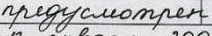

Распознанный текст: предусмотрен

Файл: photos/photo_2.jpg


Распознанный текст: выссена запись

Файл: photos/photo_9.jpg


Распознанный текст: Бельченко

Файл: photos/photo_1.jpg


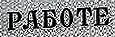

Распознанный текст: РАВОТЕ

Файл: photos/photo_7.jpg


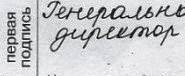

Распознанный текст: 1 директор

Файл: photos/photo_3.jpg


Распознанный текст: жетиз


In [ ]:
# ── Установка (если ещё не ставили)
# pip install torch torchvision pillow transformers accelerate

from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from transformers.utils import logging as hf_logging
import torch
import glob
from spellchecker import SpellChecker

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


# 1. Глушим подробные логи HF
hf_logging.set_verbosity_error()

# 2. Загружаем модель и токенизатор
MODEL_ID = "kazars24/trocr-base-handwritten-ru"
processor = TrOCRProcessor.from_pretrained(MODEL_ID)
model     = VisionEncoderDecoderModel.from_pretrained(MODEL_ID)
device    = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

spell = Speller('ru')

# 3. Перебираем все JPG-файлы в папке
for img_path in glob.glob('photos/*.jpg'):
    img = Image.open(img_path).convert("RGB")

    print(f"\nФайл: {img_path}")
    display(img)

    # 4. Преобразуем картинку для модели
    inputs = processor(
        img,
        return_tensors="pt",
        do_resize=True,
        do_normalize=True
    ).pixel_values.to(device)

    # 5. Генерируем результат
    with torch.no_grad():
        generated_ids = model.generate(
            inputs,
            early_stopping=True
        )

    # 6. Декодируем в текст
    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    # 7. Распознанный текст
    print(f"Распознанный текст: {text}")
    #print(f"Отредактированный текст: {correct_rus_text(text, spell)}")







# TrOCR (модель базового размера, доработанная на IAM)

https://huggingface.co/microsoft/trocr-base-handwritten